In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, hypergeom
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure,
    precision_score, recall_score, f1_score, silhouette_score,
)

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False

sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#TODO FIX NORMALIZATION FOR ATE COMPUTATION. TREAT EFFECT DIFFERENT FROM PREDICTED

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS         = 1
NUM_EPOCHS     = 200
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 20
N_CLUSTERS     = 10
RESULTS_DIR    = "results/reproducibility"

SHERLOCK_KWARGS = {
    "tau_end": 0.3,
    "tau_init": 1.5,
    # "cov_lambda": 0,
    "H_lambda": 0,
    "gate_row_repulsion_lambda": 0,
    "ce_lambda": 1e3,
    "shift": "linear",
    "l0_lambda": 10,
    # "lr": 1e-2,
    "ntc_lambda": 1e-5,
    "pert_lambda": 1,
}

os.makedirs(f"{RESULTS_DIR}/figures", exist_ok=True)
print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/reproducibility


## Data loading

In [4]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|██████████| 681/681 [00:08<00:00, 78.99it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for cluster evaluation

In [5]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

# Flat table for merging (gene, pathway)
pathways_flat = pathway_df_indexed.reset_index()

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Cluster alignment helper

In [6]:
def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
    gene_embeddings=None,
):
    """Hungarian-match predicted clusters to ground-truth pathways."""
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how="inner", validate="one_to_one",
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped   = np.array([mapping.get(cl) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average="macro", zero_division=0)
    recall    = recall_score(y_true, mapped, average="macro", zero_division=0)
    f1        = f1_score(y_true, mapped, average="macro", zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, com, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    sil = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        sil = silhouette_score(emb, mapped, metric='euclidean')

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        pur = (g[pathway_col] == majority).mean()
        rec_cl = (g[pathway_col] == majority).sum() / max((df[pathway_col] == majority).sum(), 1)
        purity_rows.append({"cluster": str(cl), "size": len(g),
                             "mapped_pathway": mapping.get(str(cl)), "purity": pur, "recall": rec_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    contingency = contingency_df.copy()
    row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    N_total = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes   = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            pval = hypergeom.sf(k - 1, N_total, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K,
                             "n": n, "N": N_total, "pval": float(pval)})
    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * max(len(enrich_df), 1), 1.0)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    df["mapped_pathway"] = mapped
    df["is_match"]       = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}),
        "mapping": mapping,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "ari": ari, "ami": ami,
        "homogeneity": hom, "completeness": com, "v_measure": vmeas,
        "silhouette": sil,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": row_norm,
        "contingency_col_norm": col_norm,
        "enrichment": enrich_df,
    }

## Reproducibility loop

Train Sherlock `N_RUNS` times independently. After each run extract:
- **W** — the (P × d) gate matrix from `model.gate(deterministic=True)`
- **rho_corr** — the (P × P) learned covariance correlation matrix
- **clusters** — hierarchical cut on the pathway-gene subset of rho_corr, then Hungarian-matched to pathways via `align_and_summarize`

In [7]:
run_results     = []
per_run_metrics = []

for run in range(N_RUNS):
    print(f"\n{'='*50}\nSherlock run {run + 1}/{N_RUNS}\n{'='*50}")

    out = slk.tl.run(
        data,
        model="vae",
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        device=DEVICE,
        latent_dim=LATENT_DIM,
        patience=PATIENCE,
        validate_every=VALIDATE_EVERY,
        seed=run,
        **SHERLOCK_KWARGS,
    )
    model = out['model']

    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    results = data.uns['results']

    # Gate matrix W: (P, d)
    W = model.gate(deterministic=True).detach().cpu().numpy()

    # Learned covariance correlation: (P, P)
    rho_corr  = np.asarray(results['rho_corr'],  dtype=float)
    rho_perts = np.asarray(results['rho_perts'])

    # Pathway-gene subset and clustering
    pert_to_idx = {name: i for i, name in enumerate(rho_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = rho_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    raw_clusters = slk.tl.cluster_rho(
        data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False
    )

    # Hungarian-match cluster labels to pathway names
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': raw_clusters})
    align_out   = align_and_summarize(clusters_df, pathways_flat)

    merged = align_out['merged'].set_index('gene')
    mapped_pathway = np.array(
        [merged.loc[g, 'mapped_pathway'] if g in merged.index else None
         for g in valid_genes],
        dtype=object,
    )

    run_results.append({
        'run':            run,
        'W':              W,
        'rho_corr':       rho_corr,
        'rho_perts':      rho_perts,
        'valid_genes':    valid_genes,
        'raw_clusters':   raw_clusters,
        'mapped_pathway': mapped_pathway,
        'align_out':      align_out,
    })

    m = align_out
    per_run_metrics.append({
        'run':          run + 1,
        'accuracy':     m['accuracy'],
        'precision':    m['precision'],
        'recall':       m['recall'],
        'f1':           m['f1'],
        'ari':          m['ari'],
        'ami':          m['ami'],
        'homogeneity':  m['homogeneity'],
        'completeness': m['completeness'],
        'v_measure':    m['v_measure'],
    })
    print(f"  accuracy={m['accuracy']:.3f}  f1={m['f1']:.3f}  ari={m['ari']:.3f}  ami={m['ami']:.3f}")

print("\nAll runs complete.")


Sherlock run 1/1
Training VAE on cuda …


Epochs: 100%|██████████| 200/200 [07:20<00:00,  2.20s/it, ATE=0.1343, CE=3.1992, ELBO=5119.8608, KLw=1.00, R2_ntc=0.9562, R2_p=0.9477, acc=0.323, pi25=0.03, pi99=0.96, tau=0.300]


  accuracy=0.555  f1=0.482  ari=0.348  ami=0.398

All runs complete.


In [9]:
slk.tl.save_results(out, path=f"{RESULTS_DIR}/reproducibility_model")

In [10]:
model = slk.tl.load_results(f"{RESULTS_DIR}/reproducibility_model")

In [11]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print("Pearson r (predicted vs observed ATE):", ate['corr'])

Pearson r (predicted vs observed ATE): 0.5042703747749329


/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


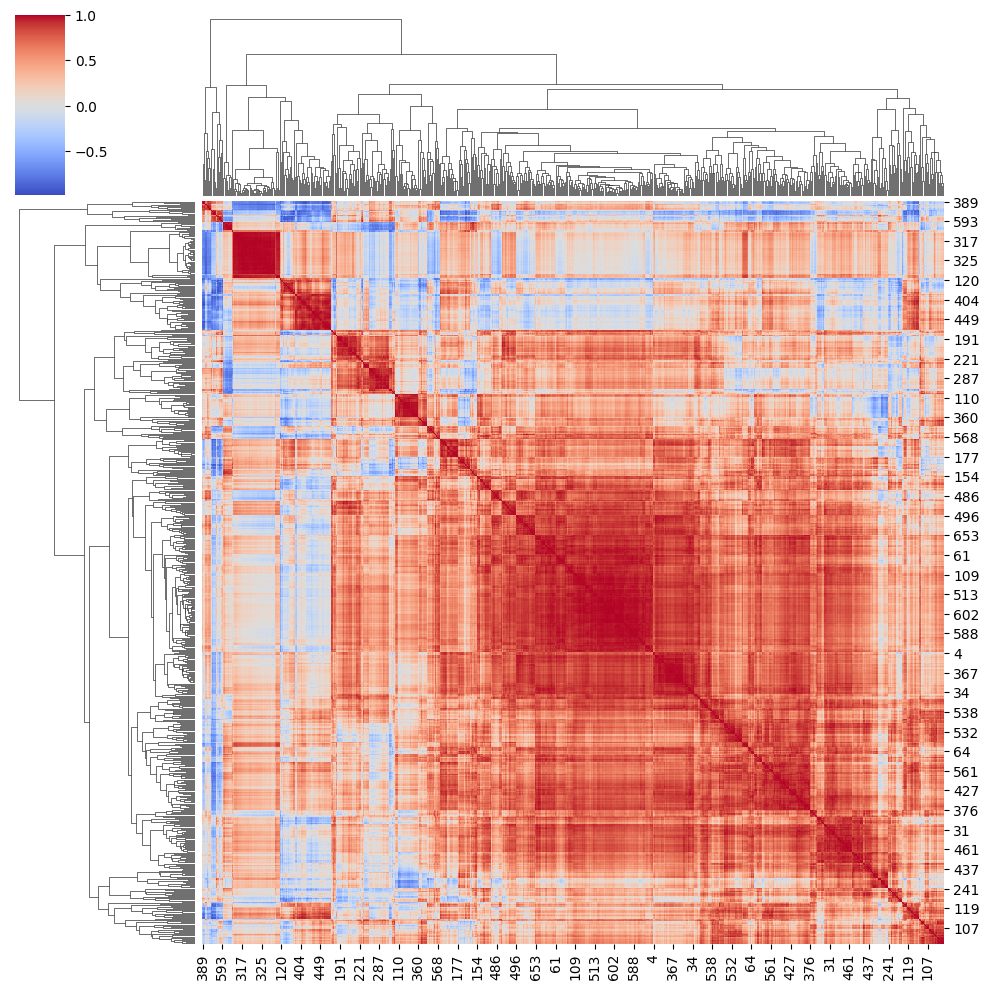

In [14]:
slk.pl.plot_corr(data)

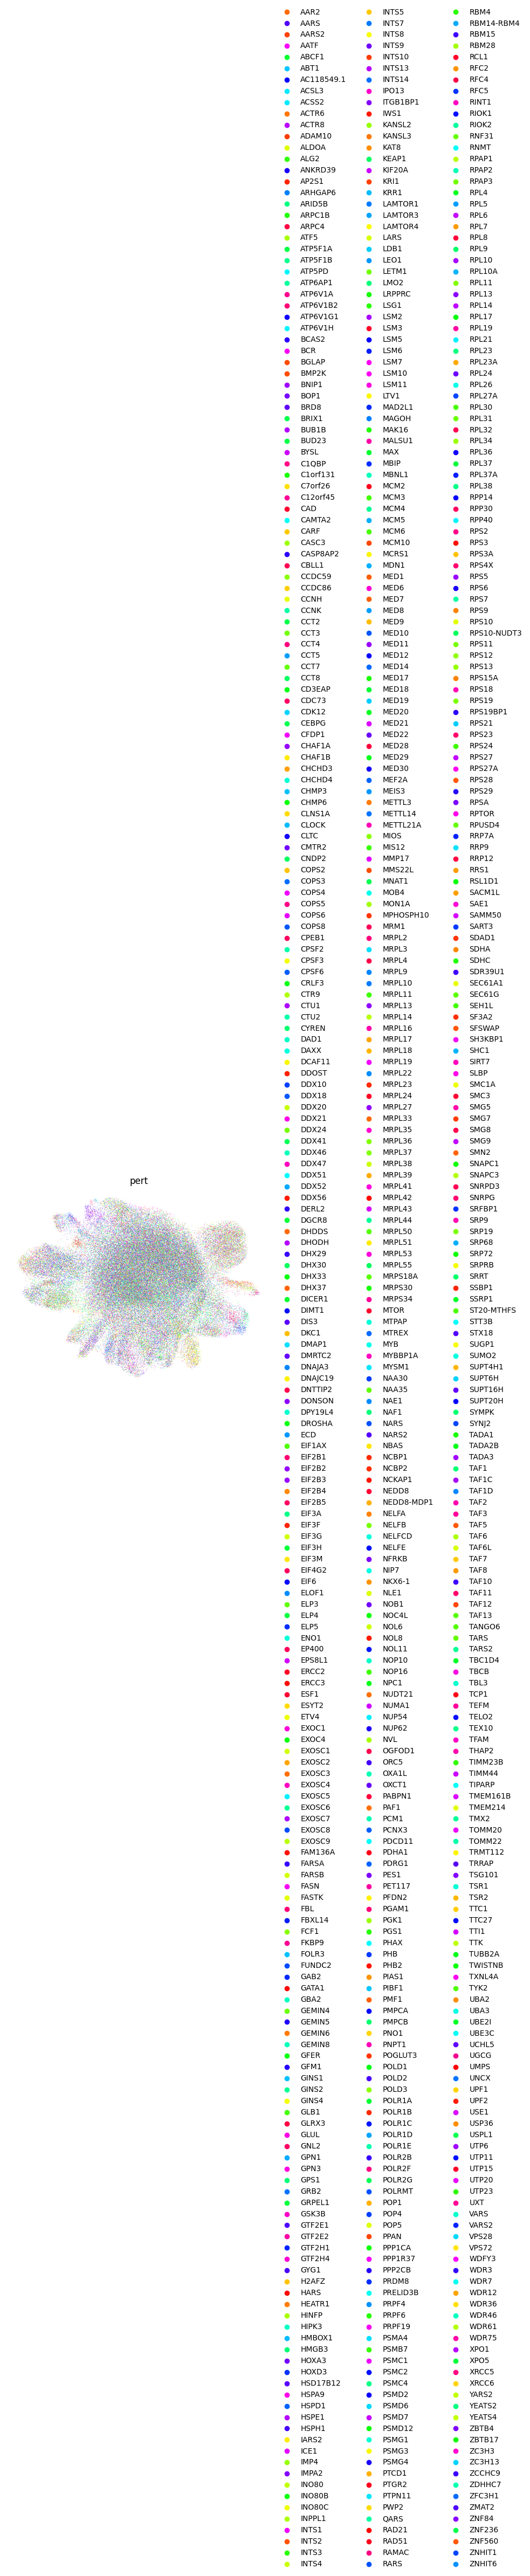

In [10]:
import scanpy as sc

p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [14]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.751  (p = 0.0e+00)
 Pearson  r = 0.749  (p = 0.0e+00)


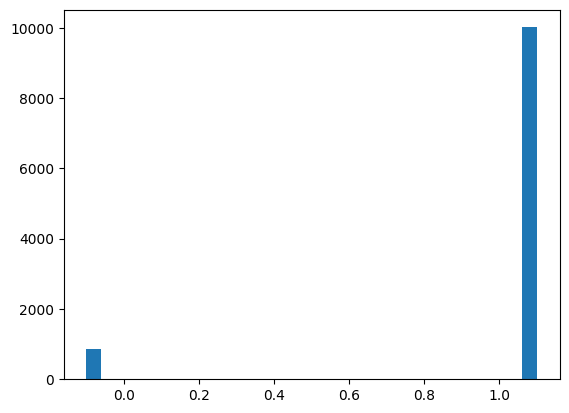

In [13]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

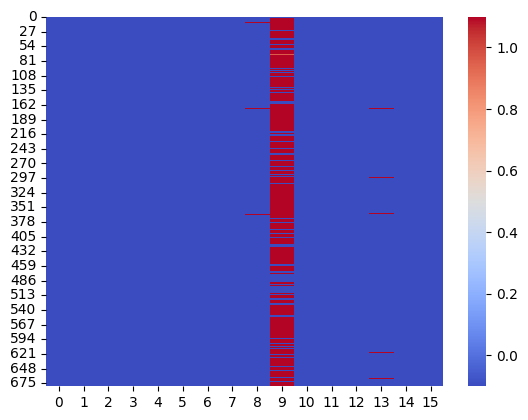

In [13]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

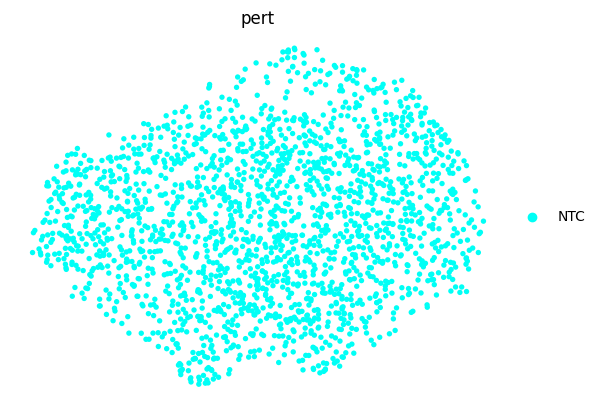

In [14]:
import scanpy as sc

p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub_ntc = data[data.obs[p_key] == NTC]

sc.pp.neighbors(sub_ntc, n_neighbors=15, use_rep='z')
sc.tl.umap(sub_ntc)

import random
n_cats = sub_ntc.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub_ntc, color='pert', palette=palette, frameon=False)

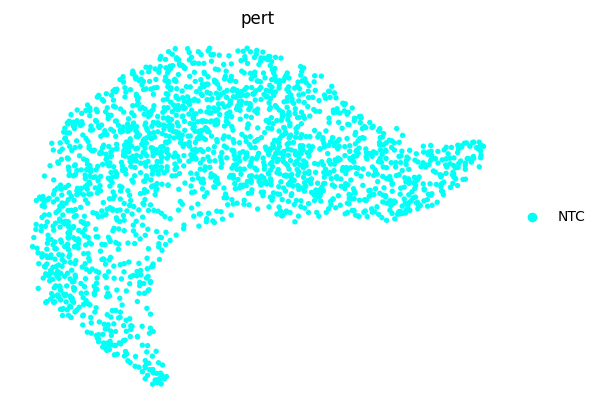

In [41]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub_ntc_raw = data[data.obs[p_key] == NTC].copy()

sc.pp.log1p(sub_ntc_raw)
sc.pp.pca(sub_ntc_raw)
sc.pp.neighbors(sub_ntc_raw)
sc.tl.umap(sub_ntc_raw)

import random
n_cats = sub_ntc_raw.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub_ntc_raw, color='pert', palette=palette, frameon=False)

In [15]:
p_key = slk.configs.get_config('pert_key')

dataset = slk.tl.PerturbMatchingDataset(data)
n_perts    = len(dataset.perturbation_dict)
latent_dim = data.obsm['z'].shape[1]

z_bar = np.zeros((n_perts, latent_dim))
for pert, pidx in dataset.perturbation_dict.items():
    mask = data.obs[p_key] == pert
    if mask.any():
        z_bar[pidx] = data.obsm['z'][mask].mean(0)

C = np.corrcoef(z_bar)

In [16]:
C = data.uns['results']['z_corr']

#Specific subsetting for replogle. Otherwise just use C directly
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]
dataset = slk.tl.PerturbMatchingDataset(data)
gene_ids = [dataset.perturbation_dict[g] for g in all_genes]
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

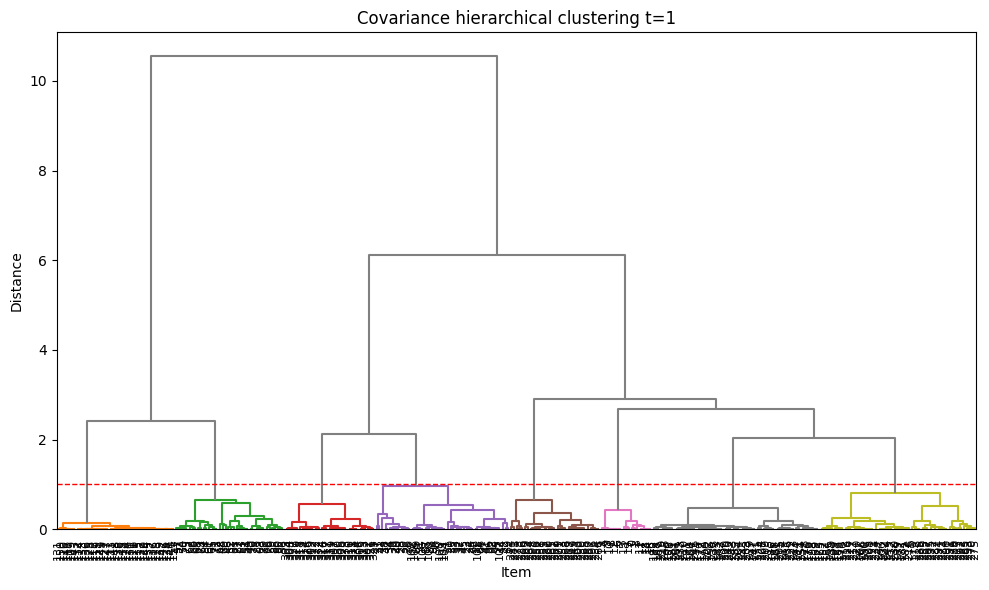

In [17]:
groups = slk.tl.cluster_rho(data, t=1, criterion='distance', method='ward', rho_corr=cov_subset, show=True)

In [18]:
gene_embeddings = pd.DataFrame(
    z_bar[gene_ids],
    index=all_genes,
)

raw_clusters = groups

# Hungarian-match cluster labels to pathway names
clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': raw_clusters})
results   = align_and_summarize(clusters_df, pathways_flat, gene_embeddings=gene_embeddings)

merged = align_out['merged'].set_index('gene')
mapped_pathway = np.array(
    [merged.loc[g, 'mapped_pathway'] if g in merged.index else None
        for g in valid_genes],
    dtype=object,
)

print("Best cluster→pathway mapping:")
for cl, pw in results["mapping"].items():
    print(f"  {cl} → {pw}")

print(f"\nGlobal alignment accuracy: {results['accuracy']:.3f}")
print(f"Precision: {results['precision']:.3f} | Recall: {results['recall']:.3f} | F1: {results['f1']:.3f}")
print(f"ARI: {results['ari']:.3f} | AMI: {results['ami']:.3f}")
print(f"Homogeneity: {results['homogeneity']:.3f} | Completeness: {results['completeness']:.3f} | V-measure: {results['v_measure']:.3f}")
print(f"Silhouette:  {results['silhouette']:.3f}")

print("\nPer-cluster purity:")
print(results["purity_df"])

Best cluster→pathway mapping:
  6 → EXOSOME
  4 → MEDIATOR_COMPLEX
  2 → MT_PROTEIN_TRANSLOCATION
  8 → NUCLEOTIDE_EXCISION_REPAIR
  1 → S39_RIBOSOMAL_UNIT
  7 → S40_RIBOSOMAL_UNIT
  5 → S60_RIBOSOMAL_UNIT
  3 → SPLICEOSOME

Global alignment accuracy: 0.761
Precision: 0.816 | Recall: 0.775 | F1: 0.776
ARI: 0.699 | AMI: 0.860
Homogeneity: 0.884 | Completeness: 0.848 | V-measure: 0.866
Silhouette:  0.401

Per-cluster purity:
         size              mapped_pathway    purity    recall
cluster                                                      
1          43          S39_RIBOSOMAL_UNIT  1.000000  1.000000
2          40    MT_PROTEIN_TRANSLOCATION  1.000000  1.000000
3          33                 SPLICEOSOME  1.000000  1.000000
4          49            MEDIATOR_COMPLEX  0.530612  1.000000
5          33          S60_RIBOSOMAL_UNIT  1.000000  0.622642
6          19                     EXOSOME  1.000000  0.950000
7          61          S40_RIBOSOMAL_UNIT  1.000000  0.628866
8          57  

## Per-run clustering metrics

In [19]:
metrics_df = pd.DataFrame(per_run_metrics).set_index('run')
print(metrics_df.round(4).to_string())
print("\nMean ± Std:")
for col in metrics_df.columns:
    v = metrics_df[col].values
    print(f"  {col:15s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

     accuracy  precision  recall      f1     ari     ami  homogeneity  completeness  v_measure
run                                                                                           
1      0.7552     0.6894  0.6624  0.6472  0.7192  0.7204       0.7494        0.7209     0.7349
2      0.8687     0.8571  0.8630  0.8560  0.7296  0.7372       0.7795        0.7241     0.7508
3      0.8657     0.8854  0.8438  0.8605  0.7257  0.7379       0.7907        0.7154     0.7512
4      0.8537     0.8529  0.8394  0.8375  0.7221  0.7328       0.7818        0.7143     0.7465
5      0.7970     0.8133  0.7889  0.7977  0.6266  0.6586       0.6953        0.6579     0.6761

Mean ± Std:
  accuracy       : 0.8281 ± 0.0447
  precision      : 0.8196 ± 0.0690
  recall         : 0.7995 ± 0.0728
  f1             : 0.7998 ± 0.0795
  ari            : 0.7046 ± 0.0391
  ami            : 0.7174 ± 0.0300
  homogeneity    : 0.7593 ± 0.0349
  completeness   : 0.7065 ± 0.0246
  v_measure      : 0.7319 ± 0.0285


## Pairwise similarity metrics

For each pair of runs compute:

1. **W correlation** — Pearson r between upper triangles of `W @ Wᵀ` (co-activation matrices, invariant to latent-dim permutation).

2. **Covariance correlation** — Pearson r between upper triangles of `rho_corr`.

3. **Cluster Jaccard (defined)** — Jaccard co-membership similarity using the raw hierarchical cluster integer labels (permutation-invariant by construction).

4. **Cluster Jaccard (matched)** — Same co-membership Jaccard but using the **Hungarian-matched** pathway labels, so identical names mean the same pathway in both runs.
   $$J = \frac{|\{(i,j): \text{same label in both runs}\}|}{|\{(i,j): \text{same label in at least one run}\}|}$$

In [20]:
def _jaccard_comembership(labels_i, labels_j):
    """Jaccard similarity of pairwise co-membership indicators."""
    n = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


pairs = list(combinations(range(N_RUNS), 2))

w_corrs           = []
cov_corrs         = []
jaccard_defined   = []
jaccard_matched   = []

for i, j in pairs:
    ri, rj = run_results[i], run_results[j]

    # --- W co-activation correlation ---
    Wi, Wj = ri['W'], rj['W']
    Ci = Wi @ Wi.T
    Cj = Wj @ Wj.T
    triu = np.triu_indices(Ci.shape[0], k=1)
    r_W, _ = pearsonr(Ci[triu], Cj[triu])
    w_corrs.append(r_W)

    # --- rho_corr correlation ---
    rho_i, rho_j = ri['rho_corr'], rj['rho_corr']
    triu_rho = np.triu_indices(rho_i.shape[0], k=1)
    fi, fj   = rho_i[triu_rho], rho_j[triu_rho]
    valid    = np.isfinite(fi) & np.isfinite(fj)
    r_cov, _ = pearsonr(fi[valid], fj[valid])
    cov_corrs.append(r_cov)

    # --- Jaccard (defined): raw hierarchical cluster integers ---
    cl_i = ri['raw_clusters'].astype(object)
    cl_j = rj['raw_clusters'].astype(object)
    jaccard_defined.append(_jaccard_comembership(cl_i, cl_j))

    # --- Jaccard (matched): Hungarian-matched pathway labels ---
    genes_i = ri['valid_genes']
    genes_j = rj['valid_genes']
    common  = [g for g in genes_i if g in set(genes_j)]

    gi_idx = {g: k for k, g in enumerate(genes_i)}
    gj_idx = {g: k for k, g in enumerate(genes_j)}

    mp_i = np.array([ri['mapped_pathway'][gi_idx[g]] for g in common], dtype=object)
    mp_j = np.array([rj['mapped_pathway'][gj_idx[g]] for g in common], dtype=object)

    both_valid = np.array([a is not None and b is not None for a, b in zip(mp_i, mp_j)])
    mp_i = mp_i[both_valid]
    mp_j = mp_j[both_valid]
    jaccard_matched.append(_jaccard_comembership(mp_i, mp_j))

pair_labels = [f"run{i+1}–run{j+1}" for i, j in pairs]

summary_df = pd.DataFrame({
    'pair':               pair_labels,
    'W_coact_pearson_r':  w_corrs,
    'rho_corr_pearson_r': cov_corrs,
    'cluster_jaccard_defined': jaccard_defined,
    'cluster_jaccard_matched': jaccard_matched,
})

print(summary_df.to_string(index=False))
print("\nMean ± Std across pairs:")
for col in ['W_coact_pearson_r', 'rho_corr_pearson_r', 'cluster_jaccard_defined', 'cluster_jaccard_matched']:
    vals = summary_df[col].dropna().values
    print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

     pair  W_coact_pearson_r  rho_corr_pearson_r  cluster_jaccard_defined  cluster_jaccard_matched
run1–run2           0.501367            0.470515                 0.533000                 0.526244
run1–run3           0.475814            0.470298                 0.543593                 0.546665
run1–run4           0.508515            0.527095                 0.556264                 0.551069
run1–run5           0.503775            0.498629                 0.511724                 0.462342
run2–run3           0.610031            0.502399                 0.567161                 0.525409
run2–run4           0.559675            0.531992                 0.552883                 0.577723
run2–run5           0.516277            0.497269                 0.556465                 0.561762
run3–run4           0.567270            0.496162                 0.594941                 0.547490
run3–run5           0.475724            0.465751                 0.509954                 0.463853
run4–run5 

## Visualisation

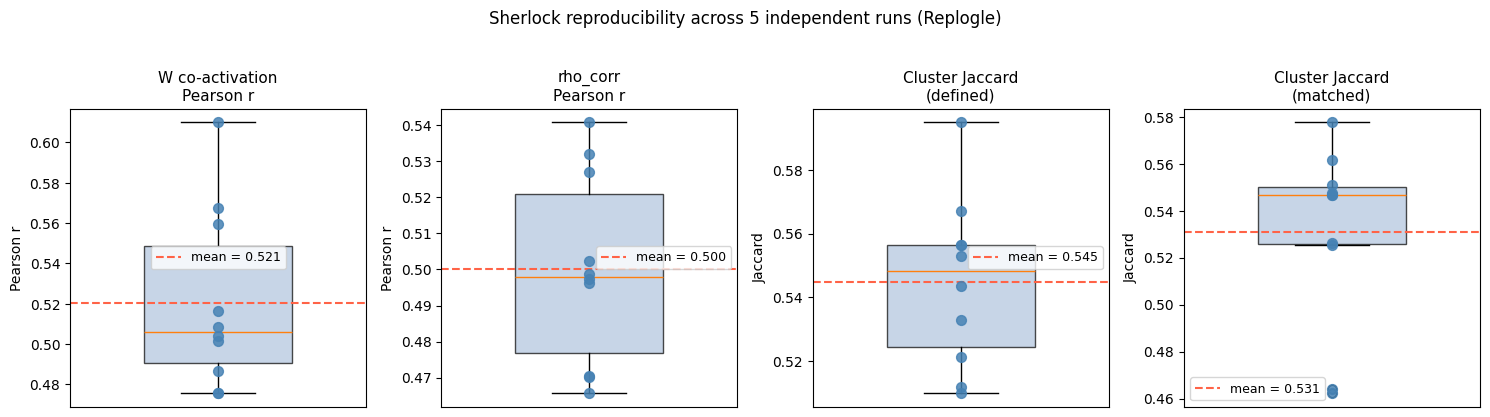

In [21]:
metric_info = [
    (w_corrs,         'W co-activation\nPearson r',   'Pearson r'),
    (cov_corrs,       'rho_corr\nPearson r',           'Pearson r'),
    (jaccard_defined, 'Cluster Jaccard\n(defined)',    'Jaccard'),
    (jaccard_matched, 'Cluster Jaccard\n(matched)',    'Jaccard'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, (values, title, ylabel) in zip(axes, metric_info):
    clean = [v for v in values if np.isfinite(v)]
    ax.boxplot(clean, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    ax.scatter([1] * len(clean), clean, color='steelblue', s=50, zorder=3, alpha=0.85)
    m = np.mean(clean)
    ax.axhline(m, color='tomato', linestyle='--', linewidth=1.5, label=f'mean = {m:.3f}')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xlim(0.5, 1.5)
    ax.legend(fontsize=9)

fig.suptitle(f'Sherlock reproducibility across {N_RUNS} independent runs (Replogle)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_boxplots.pdf', bbox_inches='tight')
plt.show()

## Pairwise heatmaps

Show the full N×N grid of pairwise similarities as heatmaps.

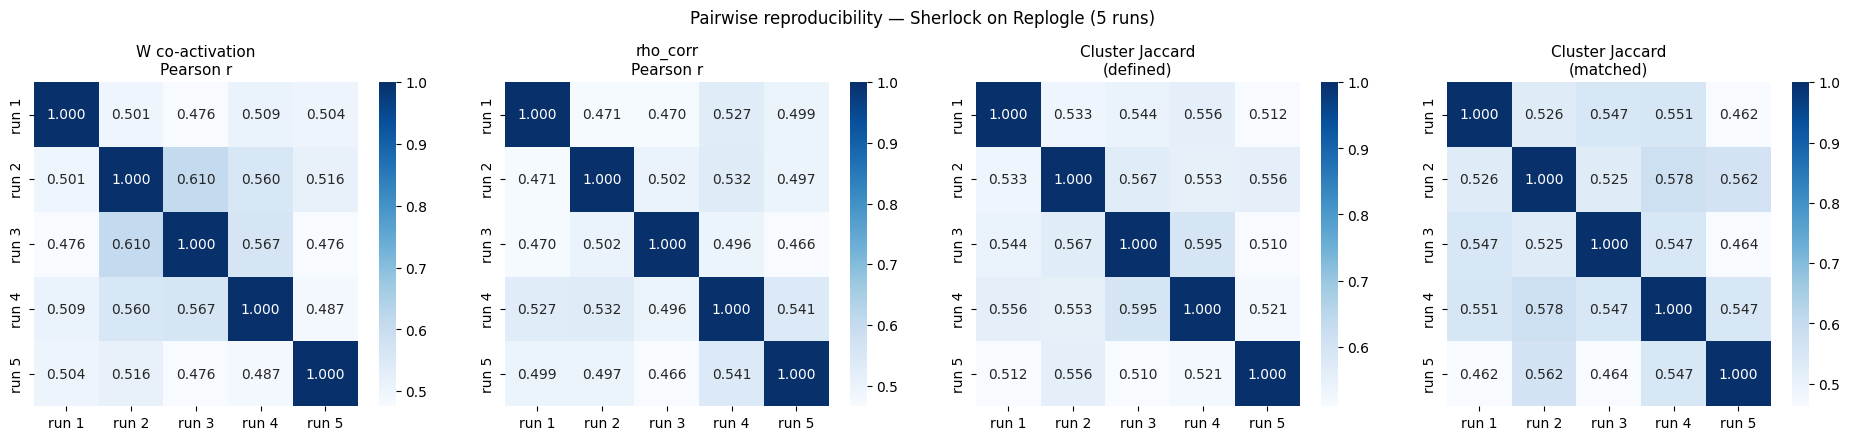

In [22]:
def to_matrix(values, n_runs, pairs):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, 1.0)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

W_mat  = to_matrix(w_corrs,         N_RUNS, pairs)
C_mat  = to_matrix(cov_corrs,       N_RUNS, pairs)
Jd_mat = to_matrix(jaccard_defined, N_RUNS, pairs)
Jm_mat = to_matrix(jaccard_matched, N_RUNS, pairs)

run_labels = [f"run {k+1}" for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

for ax, mat, title in zip(
    axes,
    [W_mat, C_mat, Jd_mat, Jm_mat],
    ['W co-activation\nPearson r', 'rho_corr\nPearson r',
     'Cluster Jaccard\n(defined)', 'Cluster Jaccard\n(matched)'],
):
    off_diag = mat[~np.eye(N_RUNS, dtype=bool)]
    vmin = np.nanmin(off_diag)
    sns.heatmap(
        mat, ax=ax, annot=True, fmt='.3f',
        vmin=vmin, vmax=1.0, cmap='Blues',
        xticklabels=run_labels, yticklabels=run_labels, square=True,
    )
    ax.set_title(title, fontsize=11)

plt.suptitle(f'Pairwise reproducibility — Sherlock on Replogle ({N_RUNS} runs)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_heatmaps.pdf', bbox_inches='tight')
plt.show()